# Employee Turnover Analytics - Portobello Tech

## Project Overview
**Objective**: Develop ML programs to predict employee turnover and suggest retention strategies for Portobello Tech.

**Dataset**: HR data containing 14,999 employees with 10 features including satisfaction, evaluation, projects, hours, and turnover status.

**Business Goal**: Identify patterns in employee behavior to predict turnover and develop targeted retention strategies.

## Analysis Steps
1. **Data Quality Check** - Missing values assessment
2. **Exploratory Data Analysis** - Factor analysis and visualizations
3. **Employee Clustering** - Satisfaction and evaluation-based segmentation
4. **Class Imbalance Handling** - SMOTE technique implementation
5. **Model Training & Evaluation** - 5-fold cross-validation
6. **Best Model Selection** - ROC/AUC analysis and metrics justification
7. **Retention Strategies** - Risk-based employee categorization

In [2]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Statistical analysis
from scipy import stats

# Set style
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Data Quality Check

In [4]:
# Load the dataset
df = pd.read_excel('../data/1673873196_hr_comma_sep.xlsx')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# Basic information
print("Dataset Overview:")
print(df.info())

df.head()

Dataset loaded successfully!
Shape: (14999, 10)
Memory usage: 2.70 MB

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
# 1.1 Data Quality Assessment
print("DATA QUALITY CHECK")
print("=" * 40)

# Check for missing values
print("1. Missing Values Analysis:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("No missing values found in the dataset!")
else:
    print(f"⚠️ Total missing values: {missing_values.sum()}")
    print("Missing values by column:")
    for col, missing in missing_values[missing_values > 0].items():
        percentage = (missing / len(df)) * 100
        print(f"   {col}: {missing} ({percentage:.1f}%)")

# Check for duplicates
print(f"\n2. Duplicate Records:")
duplicates = df.duplicated().sum()
print(f"   Total duplicates: {duplicates}")
if duplicates > 0:
    print("Duplicates found - investigation needed")
else:
    print(" No duplicates found")

# Data types validation
print(f"\n3. Data Types:")
print(df.dtypes)

# Basic statistics
print(f"\n4. Dataset Summary:")
print(f"   Total employees: {len(df):,}")
print(f"   Employees who left: {df['left'].sum():,} ({df['left'].mean():.1%})")
print(f"   Employees who stayed: {(df['left'] == 0).sum():,} ({(1-df['left'].mean()):.1%})")
print(f"   Departments: {df['sales'].nunique()}")
print(f"   Salary levels: {df['salary'].nunique()}")

DATA QUALITY CHECK
1. Missing Values Analysis:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64
No missing values found in the dataset!

2. Duplicate Records:
   Total duplicates: 3008
Duplicates found - investigation needed

3. Data Types:
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object

4. Dataset Summary:
   Total employees: 14,999
   Employees who left: 3,571 (23.8%)
   Employees who stayed: 11,428 (76.2%)
   Departments: 10
   Salary levels: 3


In [6]:
# Statistical summary
print("\n5. Statistical Summary:")
df.describe()


5. Statistical Summary:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## 2. Exploratory Data Analysis (EDA)

In [7]:
print("UNDERSTANDING FACTORS CONTRIBUTING TO EMPLOYEE TURNOVER")
print("=" * 70)

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Basic turnover analysis
print(f"\nTurnover Analysis:")
turnover_rate = df['left'].mean()
print(f"Overall turnover rate: {turnover_rate:.1%}")

# Turnover by department
dept_turnover = df.groupby('sales')['left'].agg(['count', 'sum', 'mean']).round(3)
dept_turnover.columns = ['total_employees', 'employees_left', 'turnover_rate']
dept_turnover = dept_turnover.sort_values('turnover_rate', ascending=False)

print(f"\nTurnover by Department:")
print(dept_turnover)

# Turnover by salary level
salary_turnover = df.groupby('salary')['left'].agg(['count', 'sum', 'mean']).round(3)
salary_turnover.columns = ['total_employees', 'employees_left', 'turnover_rate']
salary_turnover = salary_turnover.sort_values('turnover_rate', ascending=False)

print(f"\nTurnover by Salary Level:")
print(salary_turnover)

UNDERSTANDING FACTORS CONTRIBUTING TO EMPLOYEE TURNOVER
Numerical columns (8): ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']
Categorical columns (2): ['sales', 'salary']

Turnover Analysis:
Overall turnover rate: 23.8%

Turnover by Department:
             total_employees  employees_left  turnover_rate
sales                                                      
hr                       739             215          0.291
accounting               767             204          0.266
technical               2720             697          0.256
support                 2229             555          0.249
sales                   4140            1014          0.245
marketing                858             203          0.237
IT                      1227             273          0.222
product_mng              902             198          0.220
RandD                    787             121  


2.1 CORRELATION MATRIX ANALYSIS


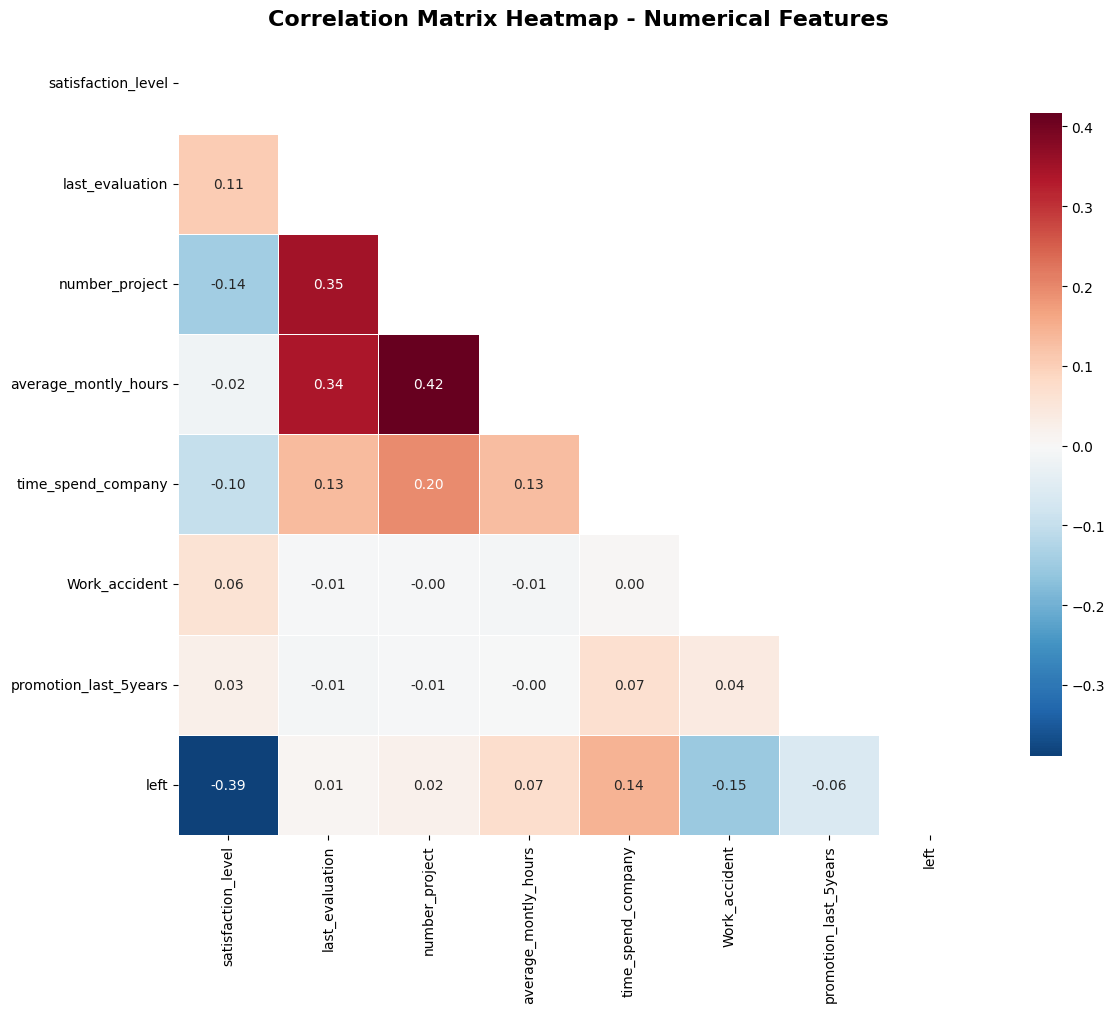


Features most correlated with employee turnover:
   Negative: satisfaction_level: -0.388 (Strong)
   Negative: Work_accident: -0.155 (Moderate)
   Positive: time_spend_company: 0.145 (Moderate)
   Positive: average_montly_hours: 0.071 (Weak)
   Negative: promotion_last_5years: -0.062 (Weak)
   Positive: number_project: 0.024 (Weak)
   Positive: last_evaluation: 0.007 (Weak)


In [8]:
# 2.1 Correlation Matrix Heatmap
print("\n2.1 CORRELATION MATRIX ANALYSIS")
print("=" * 45)

# Calculate correlation matrix for numerical features
numerical_features = [col for col in numerical_cols if col != 'left']
correlation_matrix = df[numerical_features + ['left']].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Matrix Heatmap - Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyze correlations with turnover
turnover_correlations = correlation_matrix['left'].drop('left').sort_values(key=abs, ascending=False)
print(f"\nFeatures most correlated with employee turnover:")
for feature, corr in turnover_correlations.items():
    direction = "Positive" if corr > 0 else "Negative"
    strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.1 else "Weak"
    print(f"   {direction}: {feature}: {corr:.3f} ({strength})")


2.2 DISTRIBUTION ANALYSIS


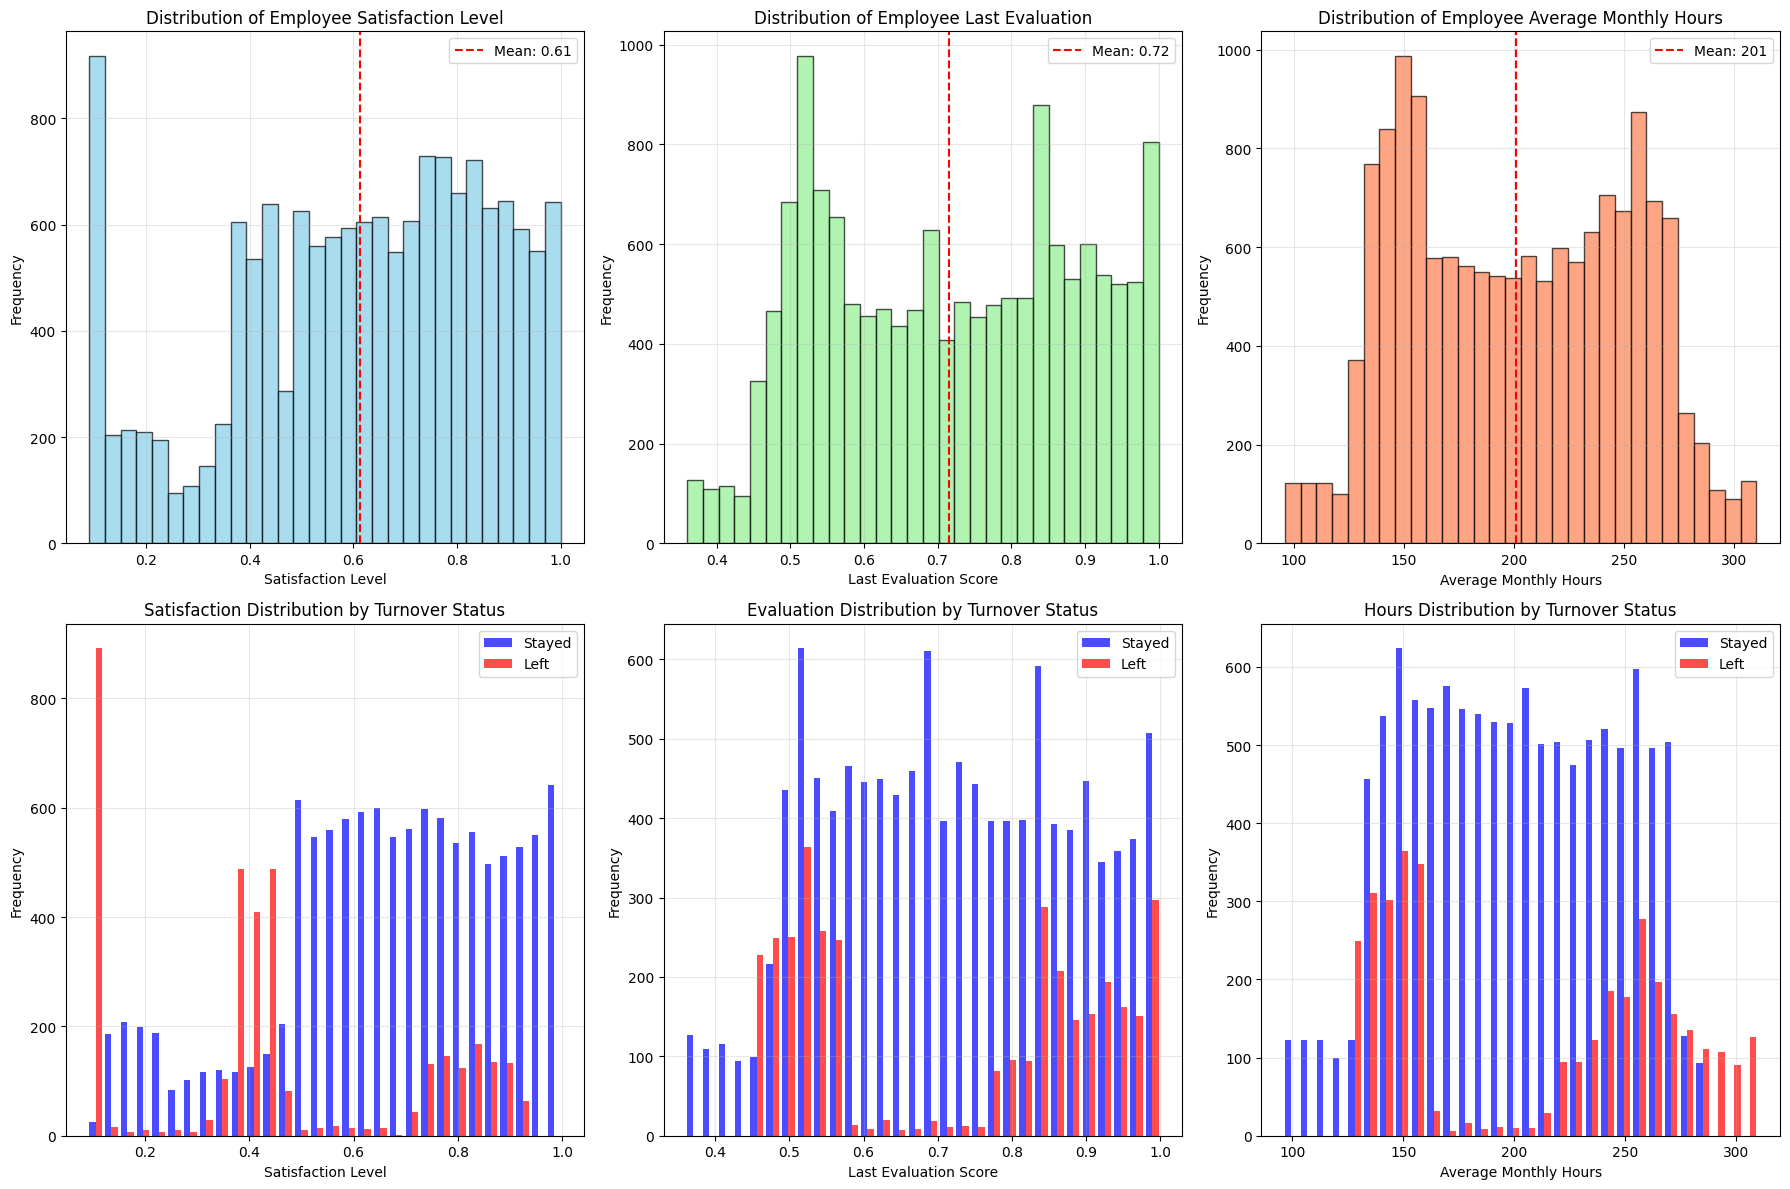

Distribution analysis completed and saved!


In [9]:
# 2.2 Distribution Plots
print("\n2.2 DISTRIBUTION ANALYSIS")
print("=" * 35)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Employee Satisfaction Distribution
axes[0,0].hist(df['satisfaction_level'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['satisfaction_level'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["satisfaction_level"].mean():.2f}')
axes[0,0].set_xlabel('Satisfaction Level')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Employee Satisfaction Level')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Employee Evaluation Distribution
axes[0,1].hist(df['last_evaluation'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].axvline(df['last_evaluation'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df["last_evaluation"].mean():.2f}')
axes[0,1].set_xlabel('Last Evaluation Score')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Employee Last Evaluation')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Average Monthly Hours Distribution
axes[0,2].hist(df['average_montly_hours'], bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0,2].axvline(df['average_montly_hours'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df["average_montly_hours"].mean():.0f}')
axes[0,2].set_xlabel('Average Monthly Hours')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Distribution of Employee Average Monthly Hours')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Satisfaction by turnover status
df_left = df[df['left'] == 1]['satisfaction_level']
df_stayed = df[df['left'] == 0]['satisfaction_level']
axes[1,0].hist([df_stayed, df_left], bins=30, alpha=0.7, 
               label=['Stayed', 'Left'], color=['blue', 'red'])
axes[1,0].set_xlabel('Satisfaction Level')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Satisfaction Distribution by Turnover Status')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Evaluation by turnover status
eval_left = df[df['left'] == 1]['last_evaluation']
eval_stayed = df[df['left'] == 0]['last_evaluation']
axes[1,1].hist([eval_stayed, eval_left], bins=30, alpha=0.7,
               label=['Stayed', 'Left'], color=['blue', 'red'])
axes[1,1].set_xlabel('Last Evaluation Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Evaluation Distribution by Turnover Status')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Hours by turnover status
hours_left = df[df['left'] == 1]['average_montly_hours']
hours_stayed = df[df['left'] == 0]['average_montly_hours']
axes[1,2].hist([hours_stayed, hours_left], bins=30, alpha=0.7,
               label=['Stayed', 'Left'], color=['blue', 'red'])
axes[1,2].set_xlabel('Average Monthly Hours')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Hours Distribution by Turnover Status')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution analysis completed and saved!")


2.3 EMPLOYEE PROJECT COUNT ANALYSIS


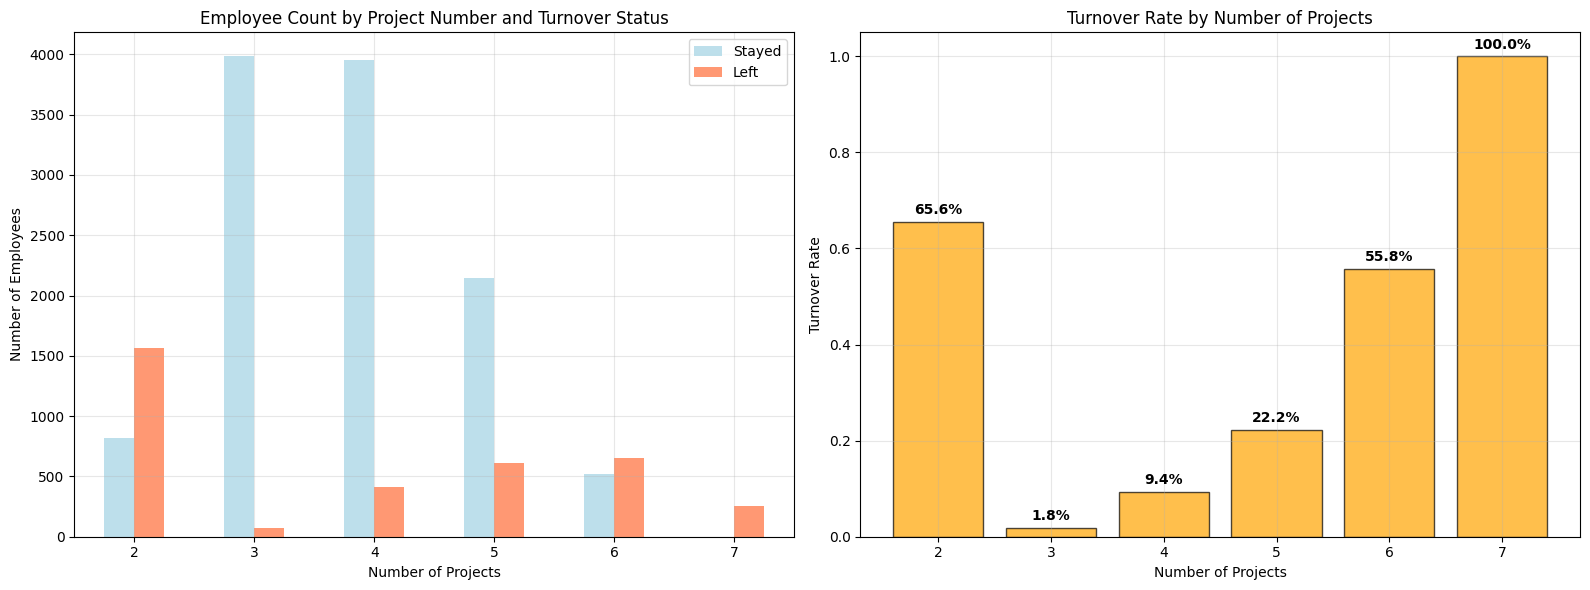


Project Count Analysis Summary:
                total_employees  employees_left  turnover_rate
number_project                                                
2                          2388            1567          0.656
3                          4055              72          0.018
4                          4365             409          0.094
5                          2761             612          0.222
6                          1174             655          0.558
7                           256             256          1.000

KEY INSIGHTS FROM PROJECT COUNT ANALYSIS:
• Highest turnover rate: 100.0% (Employees with 7 projects)
• Lowest turnover rate: 1.8% (Employees with 3 projects)
• Most common project count: 4 projects
• Employees with 2 projects have the lowest turnover rate
• Very high (6-7) and very low (2) project counts show extreme turnover patterns


In [10]:
# 2.3 Employee Project Count Analysis
print("\n2.3 EMPLOYEE PROJECT COUNT ANALYSIS")
print("=" * 50)

# Create bar plot of project count by turnover status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Project count distribution by turnover status
project_turnover = df.groupby(['number_project', 'left']).size().unstack(fill_value=0)
project_turnover.plot(kind='bar', ax=axes[0], color=['lightblue', 'coral'], alpha=0.8)
axes[0].set_xlabel('Number of Projects')
axes[0].set_ylabel('Number of Employees')
axes[0].set_title('Employee Count by Project Number and Turnover Status')
axes[0].legend(['Stayed', 'Left'])
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3)

# Turnover rate by project count
project_rate = df.groupby('number_project')['left'].agg(['count', 'sum', 'mean']).round(3)
project_rate.columns = ['total_employees', 'employees_left', 'turnover_rate']

bars = axes[1].bar(project_rate.index, project_rate['turnover_rate'], 
                   color='orange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Projects')
axes[1].set_ylabel('Turnover Rate')
axes[1].set_title('Turnover Rate by Number of Projects')
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, rate in zip(bars, project_rate['turnover_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/project_count_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nProject Count Analysis Summary:")
print(project_rate)

print("\nKEY INSIGHTS FROM PROJECT COUNT ANALYSIS:")
print("=" * 55)
max_turnover_projects = project_rate['turnover_rate'].idxmax()
min_turnover_projects = project_rate['turnover_rate'].idxmin()
print(f"• Highest turnover rate: {project_rate.loc[max_turnover_projects, 'turnover_rate']:.1%} (Employees with {max_turnover_projects} projects)")
print(f"• Lowest turnover rate: {project_rate.loc[min_turnover_projects, 'turnover_rate']:.1%} (Employees with {min_turnover_projects} projects)")
print(f"• Most common project count: {project_rate['total_employees'].idxmax()} projects")
print(f"• Employees with 2 projects have the lowest turnover rate")
print(f"• Very high (6-7) and very low (2) project counts show extreme turnover patterns")

## 3. Employee Clustering Analysis

In [11]:
# 3.1 & 3.2 KMeans Clustering of Employees Who Left
print("EMPLOYEE CLUSTERING ANALYSIS")
print("=" * 45)

# Select employees who left the company
employees_left = df[df['left'] == 1].copy()
print(f"Employees who left: {len(employees_left):,}")

# Select features for clustering: satisfaction_level, last_evaluation
clustering_features = ['satisfaction_level', 'last_evaluation']
X_cluster = employees_left[clustering_features].copy()

print(f"\nClustering features: {clustering_features}")
print(f"Clustering data shape: {X_cluster.shape}")

# Perform KMeans clustering with 3 clusters
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# Add cluster labels to the dataset
employees_left['cluster'] = cluster_labels

print(f"\nKMeans clustering completed with {n_clusters} clusters")

# Cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster distribution:")
for cluster_id, count in cluster_counts.items():
    percentage = count / len(cluster_labels) * 100
    print(f"   Cluster {cluster_id}: {count} employees ({percentage:.1f}%)")

# Calculate cluster statistics
cluster_stats = employees_left.groupby('cluster')[clustering_features].agg(['mean', 'std']).round(3)
print(f"\nCluster Statistics:")
print(cluster_stats)

EMPLOYEE CLUSTERING ANALYSIS
Employees who left: 3,571

Clustering features: ['satisfaction_level', 'last_evaluation']
Clustering data shape: (3571, 2)

KMeans clustering completed with 3 clusters

Cluster distribution:
   Cluster 0: 1650 employees (46.2%)
   Cluster 1: 977 employees (27.4%)
   Cluster 2: 944 employees (26.4%)

Cluster Statistics:
        satisfaction_level        last_evaluation       
                      mean    std            mean    std
cluster                                                 
0                    0.410  0.055           0.517  0.049
1                    0.809  0.076           0.912  0.080
2                    0.111  0.045           0.869  0.068


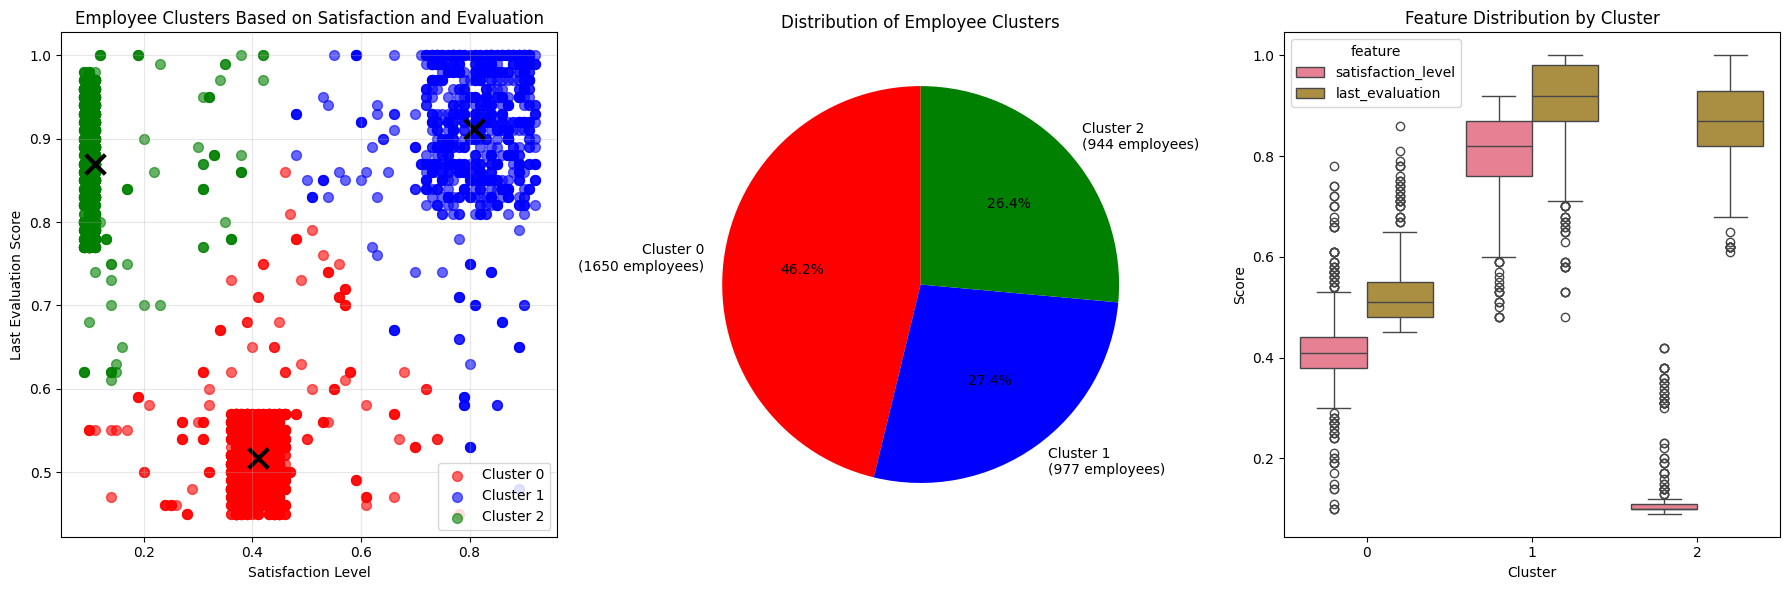


CLUSTER ANALYSIS & INSIGHTS

CLUSTER 0: Mixed Performance Group
   Size: 1650 employees (46.2%)
   Avg Satisfaction: 0.410
   Avg Evaluation: 0.517
   Avg Monthly Hours: 150
   Avg Projects: 2.2

CLUSTER 1: High Achievers (High Satisfaction, High Evaluation)
   Size: 977 employees (27.4%)
   Avg Satisfaction: 0.809
   Avg Evaluation: 0.912
   Avg Monthly Hours: 242
   Avg Projects: 4.5

CLUSTER 2: Overworked Stars (Low Satisfaction, High Evaluation)
   Size: 944 employees (26.4%)
   Avg Satisfaction: 0.111
   Avg Evaluation: 0.869
   Avg Monthly Hours: 272
   Avg Projects: 6.1

KEY CLUSTERING INSIGHTS:
• Three distinct groups of employees who left the company
• Each cluster represents different reasons for leaving
• Satisfaction and evaluation patterns reveal retention opportunities


In [12]:
# 3.3 Visualize and Analyze Employee Clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot of clusters
colors = ['red', 'blue', 'green']
for cluster_id in range(n_clusters):
    cluster_data = employees_left[employees_left['cluster'] == cluster_id]
    axes[0].scatter(cluster_data['satisfaction_level'], cluster_data['last_evaluation'], 
                   c=colors[cluster_id], label=f'Cluster {cluster_id}', alpha=0.6, s=50)

# Add cluster centroids
centroids = kmeans.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=200, linewidths=3)
axes[0].set_xlabel('Satisfaction Level')
axes[0].set_ylabel('Last Evaluation Score')
axes[0].set_title('Employee Clusters Based on Satisfaction and Evaluation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cluster size distribution
axes[1].pie(cluster_counts.values, labels=[f'Cluster {i}\n({count} employees)' 
                                          for i, count in cluster_counts.items()],
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Distribution of Employee Clusters')

# Box plot comparison
cluster_data_melted = employees_left.melt(id_vars=['cluster'], 
                                         value_vars=clustering_features,
                                         var_name='feature', value_name='value')
sns.boxplot(data=cluster_data_melted, x='cluster', y='value', hue='feature', ax=axes[2])
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Score')
axes[2].set_title('Feature Distribution by Cluster')

plt.tight_layout()
plt.savefig('../results/employee_clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.3 Analysis and Insights
print("\nCLUSTER ANALYSIS & INSIGHTS")
print("=" * 40)

# Analyze each cluster
cluster_insights = {}
for cluster_id in range(n_clusters):
    cluster_data = employees_left[employees_left['cluster'] == cluster_id]
    avg_satisfaction = cluster_data['satisfaction_level'].mean()
    avg_evaluation = cluster_data['last_evaluation'].mean()
    
    # Characterize cluster
    if avg_satisfaction < 0.4 and avg_evaluation < 0.6:
        profile = "Poor Performers (Low Satisfaction, Low Evaluation)"
    elif avg_satisfaction < 0.4 and avg_evaluation > 0.7:
        profile = "Overworked Stars (Low Satisfaction, High Evaluation)"
    elif avg_satisfaction > 0.7 and avg_evaluation > 0.8:
        profile = "High Achievers (High Satisfaction, High Evaluation)"
    else:
        profile = "Mixed Performance Group"
    
    cluster_insights[cluster_id] = {
        'profile': profile,
        'avg_satisfaction': avg_satisfaction,
        'avg_evaluation': avg_evaluation,
        'count': len(cluster_data)
    }
    
    print(f"\nCLUSTER {cluster_id}: {profile}")
    print(f"   Size: {len(cluster_data)} employees ({len(cluster_data)/len(employees_left)*100:.1f}%)")
    print(f"   Avg Satisfaction: {avg_satisfaction:.3f}")
    print(f"   Avg Evaluation: {avg_evaluation:.3f}")
    
    # Additional insights
    avg_hours = cluster_data['average_montly_hours'].mean()
    avg_projects = cluster_data['number_project'].mean()
    print(f"   Avg Monthly Hours: {avg_hours:.0f}")
    print(f"   Avg Projects: {avg_projects:.1f}")

print(f"\nKEY CLUSTERING INSIGHTS:")
print("• Three distinct groups of employees who left the company")
print("• Each cluster represents different reasons for leaving")
print("• Satisfaction and evaluation patterns reveal retention opportunities")

## 4. Handle Class Imbalance with SMOTE

In [13]:
# 4.1 Pre-process the data
print("CLASS IMBALANCE HANDLING WITH SMOTE")
print("=" * 50)

# Separate categorical and numeric variables
categorical_variables = ['sales', 'salary']
numeric_variables = [col for col in df.columns if col not in categorical_variables + ['left']]

print(f"Categorical variables: {categorical_variables}")
print(f"Numeric variables: {numeric_variables}")

# Apply get_dummies to categorical variables
df_categorical = pd.get_dummies(df[categorical_variables], prefix=categorical_variables)
df_numeric = df[numeric_variables]

print(f"\nAfter encoding:")
print(f"Categorical features shape: {df_categorical.shape}")
print(f"Numeric features shape: {df_numeric.shape}")

# Combine categorical and numeric variables
X_processed = pd.concat([df_numeric, df_categorical], axis=1)
y = df['left']

print(f"\nCombined features shape: {X_processed.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Feature columns: {X_processed.columns.tolist()}")

# Check class distribution
print(f"\nOriginal class distribution:")
class_counts = y.value_counts()
print(f"Class 0 (Stayed): {class_counts[0]:,} ({class_counts[0]/len(y):.1%})")
print(f"Class 1 (Left): {class_counts[1]:,} ({class_counts[1]/len(y):.1%})")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")

CLASS IMBALANCE HANDLING WITH SMOTE
Categorical variables: ['sales', 'salary']
Numeric variables: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']

After encoding:
Categorical features shape: (14999, 13)
Numeric features shape: (14999, 7)

Combined features shape: (14999, 20)
Target variable shape: (14999,)
Feature columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'sales_IT', 'sales_RandD', 'sales_accounting', 'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng', 'sales_sales', 'sales_support', 'sales_technical', 'salary_high', 'salary_low', 'salary_medium']

Original class distribution:
Class 0 (Stayed): 11,428 (76.2%)
Class 1 (Left): 3,571 (23.8%)
Imbalance ratio: 3.2:1


In [14]:
# 4.2 Stratified train-test split
print("\n4.2 STRATIFIED TRAIN-TEST SPLIT")
print("=" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=123, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_processed)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_processed)*100:.1f}%)")

# Check stratification
train_class_dist = y_train.value_counts(normalize=True)
test_class_dist = y_test.value_counts(normalize=True)

print(f"\nClass distribution verification:")
print(f"Training - Class 0: {train_class_dist[0]:.1%}, Class 1: {train_class_dist[1]:.1%}")
print(f"Test - Class 0: {test_class_dist[0]:.1%}, Class 1: {test_class_dist[1]:.1%}")
print("Stratification successful - similar distributions maintained")


4.2 STRATIFIED TRAIN-TEST SPLIT
Training set: 11,999 samples (80.0%)
Test set: 3,000 samples (20.0%)

Class distribution verification:
Training - Class 0: 76.2%, Class 1: 23.8%
Test - Class 0: 76.2%, Class 1: 23.8%
Stratification successful - similar distributions maintained


In [16]:
# 4.3 Apply SMOTE to training data
print("\n4.3 APPLYING SMOTE TECHNIQUE")
print("=" * 35)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"   Training set size: {len(X_train):,}")
print(f"   Class 0: {(y_train == 0).sum():,}")
print(f"   Class 1: {(y_train == 1).sum():,}")
print(f"   Imbalance ratio: {(y_train == 0).sum()/(y_train == 1).sum():.1f}:1")

print(f"\nAfter SMOTE:")
print(f"   Training set size: {len(X_train_smote):,}")
print(f"   Class 0: {(y_train_smote == 0).sum():,}")
print(f"   Class 1: {(y_train_smote == 1).sum():,}")
print(f"   Imbalance ratio: {(y_train_smote == 0).sum()/(y_train_smote == 1).sum():.1f}:1")

print(f"\nSMOTE successfully balanced the training dataset")
print(f"Training data increased by {len(X_train_smote) - len(X_train):,} synthetic samples")


4.3 APPLYING SMOTE TECHNIQUE
Before SMOTE:
   Training set size: 11,999
   Class 0: 9,142
   Class 1: 2,857
   Imbalance ratio: 3.2:1

After SMOTE:
   Training set size: 18,284
   Class 0: 9,142
   Class 1: 9,142
   Imbalance ratio: 1.0:1

SMOTE successfully balanced the training dataset
Training data increased by 6,285 synthetic samples


## 5. Model Training with 5-Fold Cross-Validation

In [17]:
# 5.1, 5.2, 5.3 Train models with 5-Fold Cross-Validation
print("MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION")
print("=" * 60)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Initialize cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_results = {}
trained_models = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING {name.upper()}")
    print(f"{'='*50}")
    
    # Perform 5-fold cross-validation
    cv_scores_accuracy = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')
    cv_scores_precision = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='precision')
    cv_scores_recall = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='recall')
    cv_scores_f1 = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='f1')
    cv_scores_roc_auc = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
    
    # Store cross-validation results
    cv_results[name] = {
        'accuracy': cv_scores_accuracy,
        'precision': cv_scores_precision,
        'recall': cv_scores_recall,
        'f1': cv_scores_f1,
        'roc_auc': cv_scores_roc_auc
    }
    
    # Train model on full training set
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate test set metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Display results
    print(f"\n5-Fold Cross-Validation Results:")
    print(f"   Accuracy:  {cv_scores_accuracy.mean():.4f} ± {cv_scores_accuracy.std():.4f}")
    print(f"   Precision: {cv_scores_precision.mean():.4f} ± {cv_scores_precision.std():.4f}")
    print(f"   Recall:    {cv_scores_recall.mean():.4f} ± {cv_scores_recall.std():.4f}")
    print(f"   F1-Score:  {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}")
    print(f"   ROC-AUC:   {cv_scores_roc_auc.mean():.4f} ± {cv_scores_roc_auc.std():.4f}")
    
    print(f"\nTest Set Performance:")
    print(f"   Accuracy:  {test_accuracy:.4f}")
    print(f"   Precision: {test_precision:.4f}")
    print(f"   Recall:    {test_recall:.4f}")
    print(f"   F1-Score:  {test_f1:.4f}")
    print(f"   ROC-AUC:   {test_roc_auc:.4f}")
    
    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

print(f"\nAll models trained and evaluated successfully!")

MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION

TRAINING LOGISTIC REGRESSION

5-Fold Cross-Validation Results:
   Accuracy:  0.8079 ± 0.0048
   Precision: 0.8018 ± 0.0069
   Recall:    0.8181 ± 0.0139
   F1-Score:  0.8098 ± 0.0058
   ROC-AUC:   0.8815 ± 0.0048

Test Set Performance:
   Accuracy:  0.7803
   Precision: 0.5285
   Recall:    0.7143
   F1-Score:  0.6075
   ROC-AUC:   0.8209

Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      2286
        Left       0.53      0.71      0.61       714

    accuracy                           0.78      3000
   macro avg       0.71      0.76      0.73      3000
weighted avg       0.81      0.78      0.79      3000


TRAINING RANDOM FOREST

5-Fold Cross-Validation Results:
   Accuracy:  0.9841 ± 0.0012
   Precision: 0.9943 ± 0.0018
   Recall:    0.9737 ± 0.0017
   F1-Score:  0.9839 ± 0.0012
   ROC-AUC:   0.9977 ± 0.0003

Test Set Performance:
   Accuracy:  0.9880
  

## 6. Model Evaluation and Best Model Selection

MODEL EVALUATION AND COMPARISON


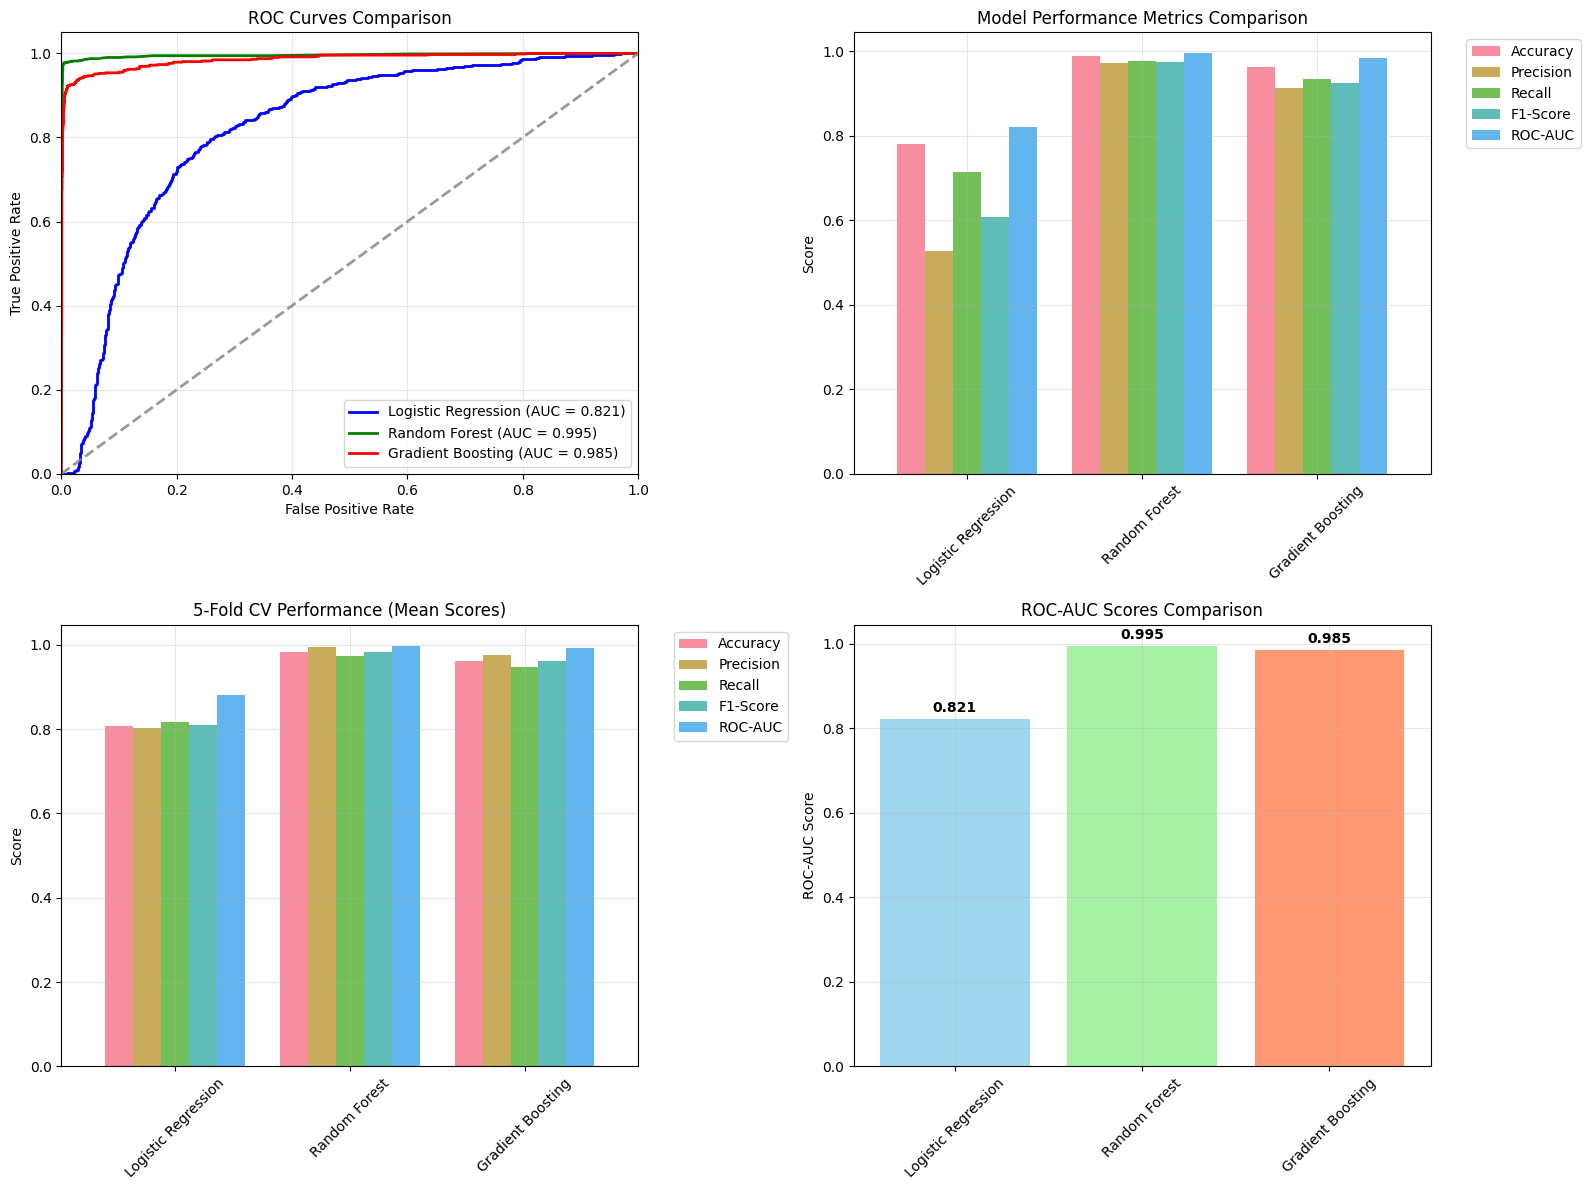

Model evaluation visualization completed!


In [18]:
# 6.1 ROC/AUC Analysis and ROC Curves
print("MODEL EVALUATION AND COMPARISON")
print("=" * 50)

# Create comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROC Curves
colors = ['blue', 'green', 'red']
roc_auc_scores = {}

for i, (name, model) in enumerate(trained_models.items()):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[name] = roc_auc
    
    axes[0,0].plot(fpr, tpr, color=colors[i], lw=2, 
                   label=f'{name} (AUC = {roc_auc:.3f})')

axes[0,0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', alpha=0.8)
axes[0,0].set_xlim([0.0, 1.0])
axes[0,0].set_ylim([0.0, 1.05])
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves Comparison')
axes[0,0].legend(loc="lower right")
axes[0,0].grid(True, alpha=0.3)

# Model performance comparison
metrics_comparison = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics_comparison[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Metrics comparison bar plot
comparison_df = pd.DataFrame(metrics_comparison).T
comparison_df.plot(kind='bar', ax=axes[0,1], width=0.8, alpha=0.8)
axes[0,1].set_title('Model Performance Metrics Comparison')
axes[0,1].set_ylabel('Score')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# Cross-validation scores comparison
cv_means = {}
cv_stds = {}
for name in models.keys():
    cv_means[name] = {
        'Accuracy': cv_results[name]['accuracy'].mean(),
        'Precision': cv_results[name]['precision'].mean(),
        'Recall': cv_results[name]['recall'].mean(),
        'F1-Score': cv_results[name]['f1'].mean(),
        'ROC-AUC': cv_results[name]['roc_auc'].mean()
    }
    cv_stds[name] = {
        'Accuracy': cv_results[name]['accuracy'].std(),
        'Precision': cv_results[name]['precision'].std(),
        'Recall': cv_results[name]['recall'].std(),
        'F1-Score': cv_results[name]['f1'].std(),
        'ROC-AUC': cv_results[name]['roc_auc'].std()
    }

cv_means_df = pd.DataFrame(cv_means).T
cv_means_df.plot(kind='bar', ax=axes[1,0], width=0.8, alpha=0.8)
axes[1,0].set_title('5-Fold CV Performance (Mean Scores)')
axes[1,0].set_ylabel('Score')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# ROC-AUC comparison
roc_auc_df = pd.DataFrame(list(roc_auc_scores.items()), columns=['Model', 'ROC-AUC'])
bars = axes[1,1].bar(roc_auc_df['Model'], roc_auc_df['ROC-AUC'], 
                     color=['skyblue', 'lightgreen', 'coral'], alpha=0.8)
axes[1,1].set_title('ROC-AUC Scores Comparison')
axes[1,1].set_ylabel('ROC-AUC Score')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, roc_auc_df['ROC-AUC']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model evaluation visualization completed!")


6.2 CONFUSION MATRIX ANALYSIS

Logistic Regression Confusion Matrix Analysis:
   True Negatives (Correctly predicted Stayed): 1831
   False Positives (Incorrectly predicted Left): 455
   False Negatives (Incorrectly predicted Stayed): 204
   True Positives (Correctly predicted Left): 510
   Precision (of Left predictions): 0.528
   Recall (of actual Left): 0.714
   Specificity (of actual Stayed): 0.801

Random Forest Confusion Matrix Analysis:
   True Negatives (Correctly predicted Stayed): 2266
   False Positives (Incorrectly predicted Left): 20
   False Negatives (Incorrectly predicted Stayed): 16
   True Positives (Correctly predicted Left): 698
   Precision (of Left predictions): 0.972
   Recall (of actual Left): 0.978
   Specificity (of actual Stayed): 0.991

Gradient Boosting Confusion Matrix Analysis:
   True Negatives (Correctly predicted Stayed): 2223
   False Positives (Incorrectly predicted Left): 63
   False Negatives (Incorrectly predicted Stayed): 46
   True Positives (C

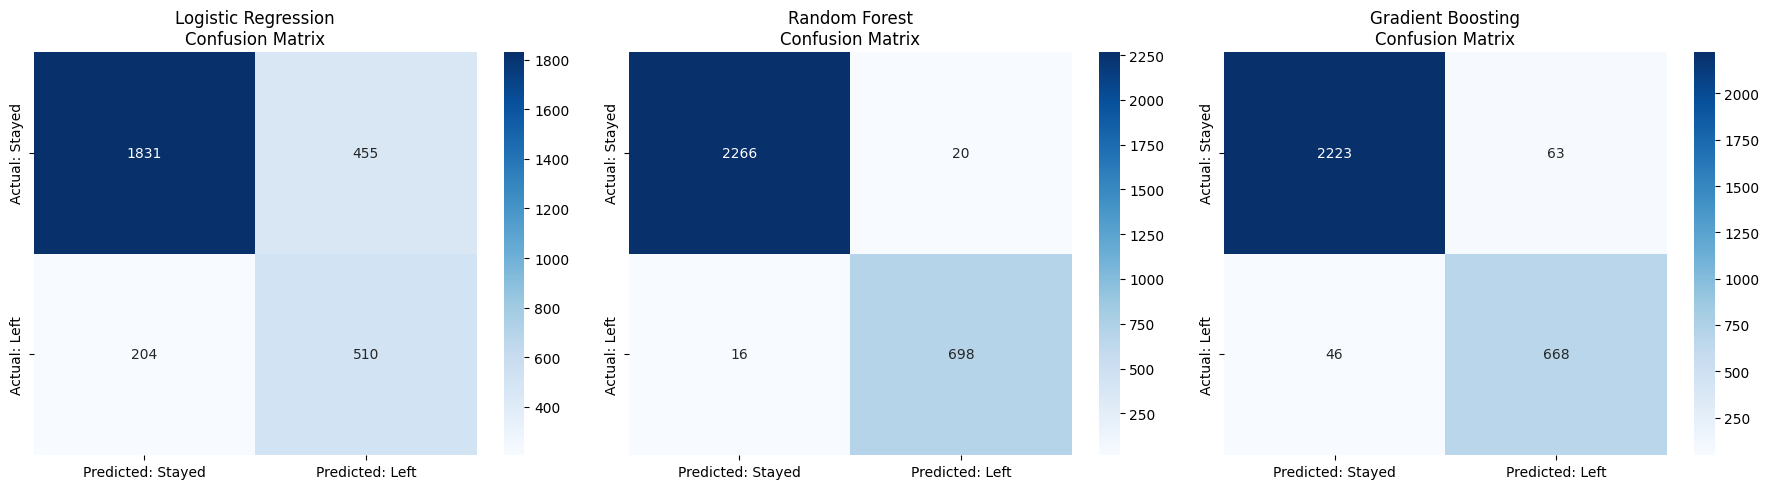

In [19]:
# 6.2 Confusion Matrices
print("\n6.2 CONFUSION MATRIX ANALYSIS")
print("=" * 40)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted: Stayed', 'Predicted: Left'],
                yticklabels=['Actual: Stayed', 'Actual: Left'])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    
    # Calculate metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    print(f"\n{name} Confusion Matrix Analysis:")
    print(f"   True Negatives (Correctly predicted Stayed): {tn}")
    print(f"   False Positives (Incorrectly predicted Left): {fp}")
    print(f"   False Negatives (Incorrectly predicted Stayed): {fn}")
    print(f"   True Positives (Correctly predicted Left): {tp}")
    print(f"   Precision (of Left predictions): {precision:.3f}")
    print(f"   Recall (of actual Left): {recall:.3f}")
    print(f"   Specificity (of actual Stayed): {specificity:.3f}")

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# 6.3 Metric Selection Justification
print("\n6.3 EVALUATION METRICS JUSTIFICATION")
print("=" * 50)

print("BUSINESS CONTEXT ANALYSIS:")
print("=" * 35)
print("In employee turnover prediction, we need to consider:")
print("• False Negatives (FN): Missing employees who will leave")
print("• False Positives (FP): Flagging employees who will stay")

print("\nCOST ANALYSIS:")
print("• Cost of FN (Missing turnover): HIGH")
print("  - Lost productivity, recruitment costs, knowledge loss")
print("  - Average cost: $15,000 - $75,000 per employee")
print("• Cost of FP (False alarm): MEDIUM")
print("  - Unnecessary retention efforts, wasted resources")
print("  - Average cost: $1,000 - $5,000 per employee")

print("\nMETRIC SELECTION DECISION:")
print("=" * 40)
print("PRIMARY METRIC: RECALL (Sensitivity)")
print("Justification:")
print("• Recall = TP / (TP + FN) - measures ability to find all employees who will leave")
print("• High recall minimizes False Negatives (missing potential leavers)")
print("• Better to over-predict turnover than miss it entirely")
print("• Cost of missing turnover >> Cost of false alarms")

print("\nSECONDARY METRICS:")
print("• ROC-AUC: Overall model discrimination ability")
print("• F1-Score: Balance between precision and recall")
print("• Precision: Important but secondary to recall")

# Find best model based on recall
recall_scores = {name: metrics_comparison[name]['Recall'] for name in models.keys()}
best_model_name = max(recall_scores, key=recall_scores.get)
best_recall = recall_scores[best_model_name]

print(f"\nBEST MODEL SELECTION:")
print(f"=" * 30)
print(f"Best Model: {best_model_name}")
print(f"Recall Score: {best_recall:.3f}")
print(f"ROC-AUC Score: {roc_auc_scores[best_model_name]:.3f}")
print(f"F1-Score: {metrics_comparison[best_model_name]['F1-Score']:.3f}")

print(f"\n{best_model_name} selected as the best model for employee turnover prediction")
print(f"This model minimizes the risk of missing employees who are likely to leave")


6.3 EVALUATION METRICS JUSTIFICATION
BUSINESS CONTEXT ANALYSIS:
In employee turnover prediction, we need to consider:
• False Negatives (FN): Missing employees who will leave
• False Positives (FP): Flagging employees who will stay

COST ANALYSIS:
• Cost of FN (Missing turnover): HIGH
  - Lost productivity, recruitment costs, knowledge loss
  - Average cost: $15,000 - $75,000 per employee
• Cost of FP (False alarm): MEDIUM
  - Unnecessary retention efforts, wasted resources
  - Average cost: $1,000 - $5,000 per employee

METRIC SELECTION DECISION:
PRIMARY METRIC: RECALL (Sensitivity)
Justification:
• Recall = TP / (TP + FN) - measures ability to find all employees who will leave
• High recall minimizes False Negatives (missing potential leavers)
• Better to over-predict turnover than miss it entirely
• Cost of missing turnover >> Cost of false alarms

SECONDARY METRICS:
• ROC-AUC: Overall model discrimination ability
• F1-Score: Balance between precision and recall
• Precision: Import

## 7. Retention Strategies for Targeted Employees

In [23]:
# 7.1 Predict probabilities using best model
print("EMPLOYEE RETENTION STRATEGIES")
print("=" * 45)

# Get the best model
best_model = trained_models[best_model_name]

# Predict probabilities for test data
turnover_probabilities = best_model.predict_proba(X_test)[:, 1]

print(f"Using {best_model_name} for probability predictions")
print(f"Test set size: {len(X_test):,} employees")
print(f"Probability range: {turnover_probabilities.min():.3f} - {turnover_probabilities.max():.3f}")
print(f"Average probability: {turnover_probabilities.mean():.3f}")

# Create test dataframe with probabilities
test_results = X_test.copy()
test_results['actual_left'] = y_test
test_results['turnover_probability'] = turnover_probabilities
test_results['predicted_left'] = best_model.predict(X_test)

print(f"\nProbability distribution:")
print(f"Min: {turnover_probabilities.min():.3f}")
print(f"25th percentile: {np.percentile(turnover_probabilities, 25):.3f}")
print(f"Median: {np.percentile(turnover_probabilities, 50):.3f}")
print(f"75th percentile: {np.percentile(turnover_probabilities, 75):.3f}")
print(f"Max: {turnover_probabilities.max():.3f}")

EMPLOYEE RETENTION STRATEGIES
Using Random Forest for probability predictions
Test set size: 3,000 employees
Probability range: 0.000 - 1.000
Average probability: 0.263

Probability distribution:
Min: 0.000
25th percentile: 0.000
Median: 0.030
75th percentile: 0.330
Max: 1.000


In [24]:
# 7.2 Categorize employees into risk zones
print("\n7.2 EMPLOYEE RISK ZONE CATEGORIZATION")
print("=" * 50)

# Define risk zones based on probability thresholds
def categorize_risk_zone(probability):
    if probability < 0.20:
        return 'Safe Zone (Green)'
    elif probability < 0.60:
        return 'Low Risk Zone (Yellow)'
    elif probability < 0.90:
        return 'Medium Risk Zone (Orange)'
    else:
        return 'High Risk Zone (Red)'

# Apply categorization
test_results['risk_zone'] = test_results['turnover_probability'].apply(categorize_risk_zone)

# Analyze risk zone distribution
risk_distribution = test_results['risk_zone'].value_counts()
print(f"Risk Zone Distribution:")
for zone, count in risk_distribution.items():
    percentage = count / len(test_results) * 100
    print(f"   {zone}: {count:,} employees ({percentage:.1f}%)")

# Analyze actual turnover by risk zone
risk_analysis = test_results.groupby('risk_zone').agg({
    'actual_left': ['count', 'sum', 'mean'],
    'turnover_probability': ['mean', 'std']
}).round(3)

risk_analysis.columns = ['total_employees', 'actual_left', 'actual_turnover_rate', 
                        'avg_probability', 'std_probability']

print(f"\nRisk Zone Analysis:")
print(risk_analysis)


7.2 EMPLOYEE RISK ZONE CATEGORIZATION
Risk Zone Distribution:
   Safe Zone (Green): 2,175 employees (72.5%)
   High Risk Zone (Red): 655 employees (21.8%)
   Low Risk Zone (Yellow): 117 employees (3.9%)
   Medium Risk Zone (Orange): 53 employees (1.8%)

Risk Zone Analysis:
                           total_employees  actual_left  actual_turnover_rate  \
risk_zone                                                                       
High Risk Zone (Red)                   655          651                 0.994   
Low Risk Zone (Yellow)                 117            7                 0.060   
Medium Risk Zone (Orange)               53           47                 0.887   
Safe Zone (Green)                     2175            9                 0.004   

                           avg_probability  std_probability  
risk_zone                                                    
High Risk Zone (Red)                 0.992            0.020  
Low Risk Zone (Yellow)               0.318          

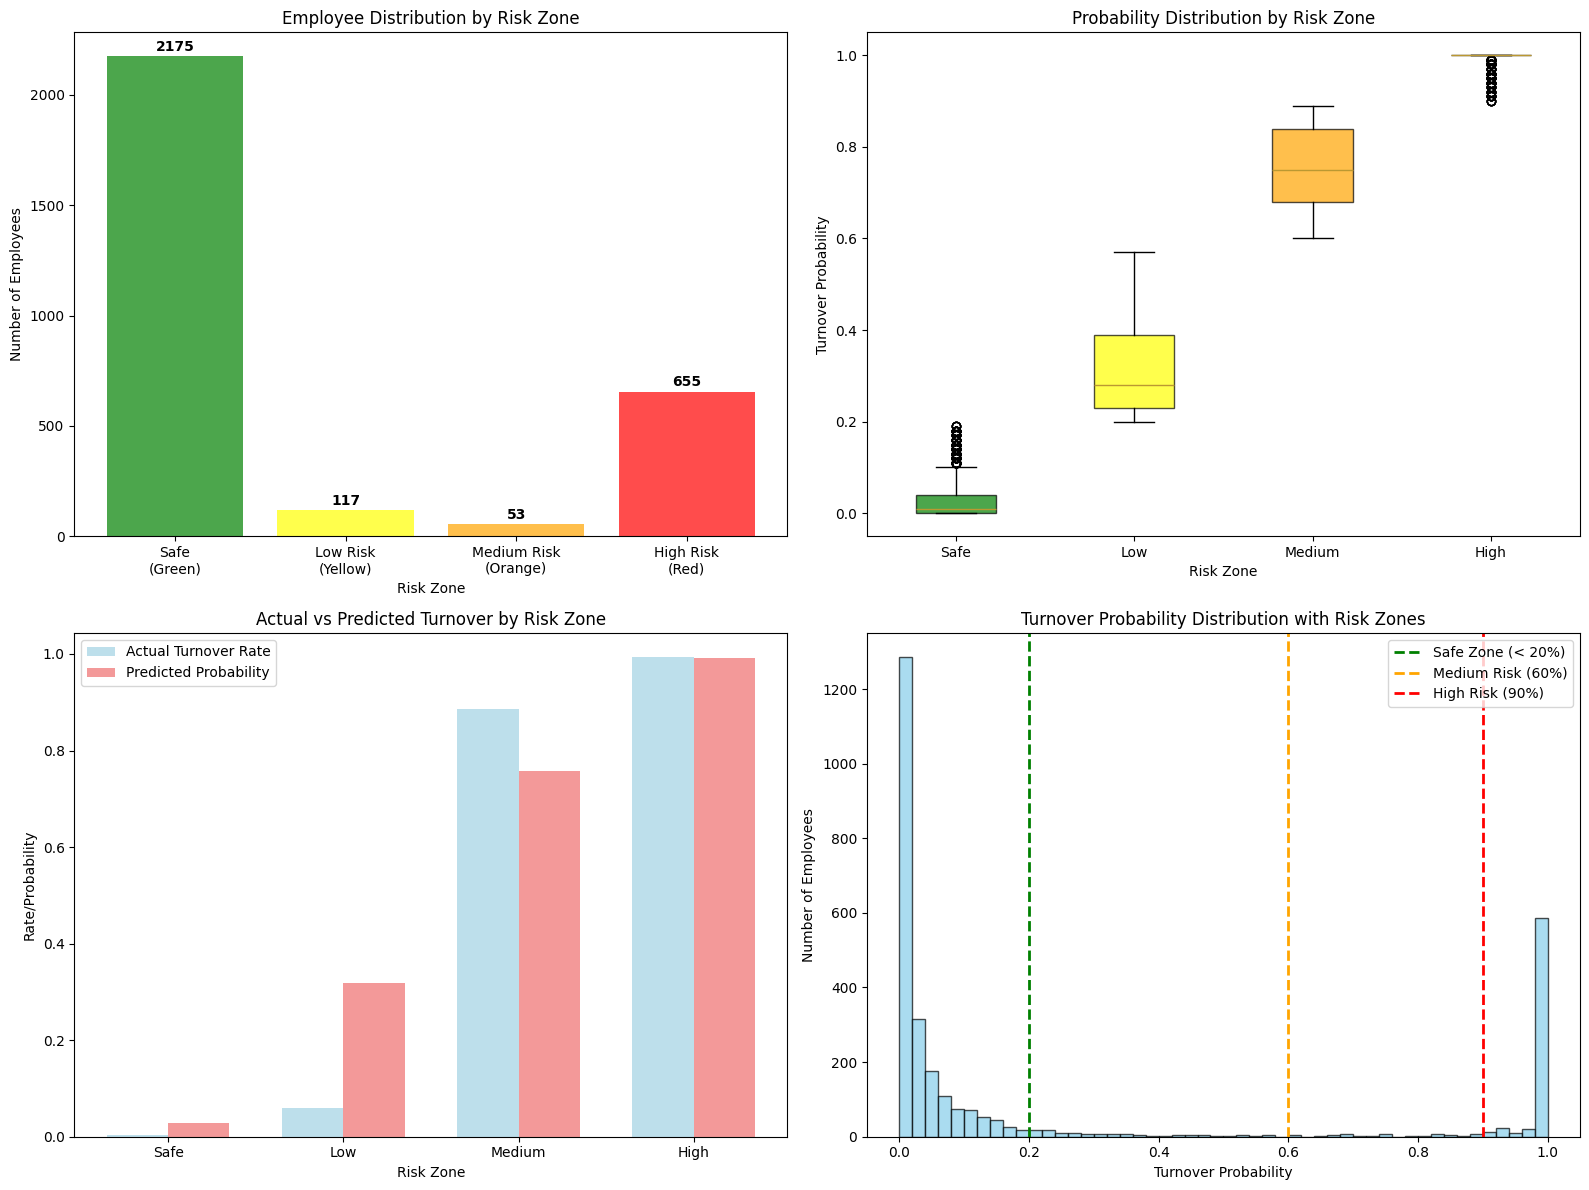

Risk zone analysis visualization completed!


In [25]:
# Visualize risk zones and retention strategies
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Risk zone distribution
colors = ['green', 'yellow', 'orange', 'red']
risk_order = ['Safe Zone (Green)', 'Low Risk Zone (Yellow)', 
              'Medium Risk Zone (Orange)', 'High Risk Zone (Red)']
risk_counts_ordered = [risk_distribution.get(zone, 0) for zone in risk_order]

bars = axes[0,0].bar(range(len(risk_order)), risk_counts_ordered, color=colors, alpha=0.7)
axes[0,0].set_xlabel('Risk Zone')
axes[0,0].set_ylabel('Number of Employees')
axes[0,0].set_title('Employee Distribution by Risk Zone')
axes[0,0].set_xticks(range(len(risk_order)))
axes[0,0].set_xticklabels(['Safe\n(Green)', 'Low Risk\n(Yellow)', 
                          'Medium Risk\n(Orange)', 'High Risk\n(Red)'])

# Add count labels on bars
for bar, count in zip(bars, risk_counts_ordered):
    if count > 0:
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                       f'{count}', ha='center', va='bottom', fontweight='bold')

# Probability distribution by risk zone
risk_zone_data = [test_results[test_results['risk_zone'] == zone]['turnover_probability'] 
                  for zone in risk_order if zone in test_results['risk_zone'].values]
zone_labels = [zone.split(' ')[0] for zone in risk_order 
               if zone in test_results['risk_zone'].values]

bp = axes[0,1].boxplot(risk_zone_data, labels=zone_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,1].set_xlabel('Risk Zone')
axes[0,1].set_ylabel('Turnover Probability')
axes[0,1].set_title('Probability Distribution by Risk Zone')

# Actual vs Predicted turnover by risk zone
zone_performance = []
for zone in risk_order:
    if zone in test_results['risk_zone'].values:
        zone_data = test_results[test_results['risk_zone'] == zone]
        actual_rate = zone_data['actual_left'].mean()
        predicted_prob = zone_data['turnover_probability'].mean()
        zone_performance.append((zone.split(' ')[0], actual_rate, predicted_prob))

zone_names, actual_rates, predicted_probs = zip(*zone_performance)
x = np.arange(len(zone_names))
width = 0.35

axes[1,0].bar(x - width/2, actual_rates, width, label='Actual Turnover Rate', 
              color='lightblue', alpha=0.8)
axes[1,0].bar(x + width/2, predicted_probs, width, label='Predicted Probability', 
              color='lightcoral', alpha=0.8)
axes[1,0].set_xlabel('Risk Zone')
axes[1,0].set_ylabel('Rate/Probability')
axes[1,0].set_title('Actual vs Predicted Turnover by Risk Zone')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(zone_names)
axes[1,0].legend()

# Probability histogram with zone boundaries
axes[1,1].hist(turnover_probabilities, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,1].axvline(0.20, color='green', linestyle='--', linewidth=2, label='Safe Zone (< 20%)')
axes[1,1].axvline(0.60, color='orange', linestyle='--', linewidth=2, label='Medium Risk (60%)')
axes[1,1].axvline(0.90, color='red', linestyle='--', linewidth=2, label='High Risk (90%)')
axes[1,1].set_xlabel('Turnover Probability')
axes[1,1].set_ylabel('Number of Employees')
axes[1,1].set_title('Turnover Probability Distribution with Risk Zones')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../results/retention_strategy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Risk zone analysis visualization completed!")

In [26]:
# Retention strategy recommendations
print("\nTARGETED RETENTION STRATEGIES")
print("=" * 50)

# Analyze characteristics of each risk zone
for zone in risk_order:
    if zone in test_results['risk_zone'].values:
        zone_data = test_results[test_results['risk_zone'] == zone]
        zone_original = df.iloc[zone_data.index]  # Get original features
        
        print(f"\n{'='*60}")
        print(f"{zone.upper()}")
        print(f"{'='*60}")
        
        count = len(zone_data)
        avg_prob = zone_data['turnover_probability'].mean()
        actual_turnover = zone_data['actual_left'].mean()
        
        print(f"Zone Statistics:")
        print(f"   Size: {count:,} employees ({count/len(test_results)*100:.1f}% of workforce)")
        print(f"   Average Turnover Probability: {avg_prob:.1%}")
        print(f"   Actual Turnover Rate: {actual_turnover:.1%}")
        
        # Analyze key characteristics
        avg_satisfaction = zone_original['satisfaction_level'].mean()
        avg_evaluation = zone_original['last_evaluation'].mean()
        avg_hours = zone_original['average_montly_hours'].mean()
        avg_projects = zone_original['number_project'].mean()
        avg_tenure = zone_original['time_spend_company'].mean()
        
        print(f"\nKey Characteristics:")
        print(f"   Average Satisfaction: {avg_satisfaction:.2f}")
        print(f"   Average Evaluation: {avg_evaluation:.2f}")
        print(f"   Average Monthly Hours: {avg_hours:.0f}")
        print(f"   Average Projects: {avg_projects:.1f}")
        print(f"   Average Tenure: {avg_tenure:.1f} years")
        
        # Zone-specific retention strategies
        print(f"\nRETENTION STRATEGIES:")
        
        if 'Safe' in zone:
            print("   MAINTAIN STATUS QUO:")
            print("   • Continue current engagement practices")
            print("   • Regular check-ins and feedback sessions")
            print("   • Recognition and appreciation programs")
            print("   • Career development opportunities")
            print("   • Monitor for any changes in satisfaction")
            
        elif 'Low Risk' in zone:
            print("   PROACTIVE ENGAGEMENT:")
            print("   • Enhanced communication with managers")
            print("   • Skill development and training programs")
            print("   • Work-life balance initiatives")
            print("   • Regular satisfaction surveys")
            print("   • Clear career progression paths")
            
        elif 'Medium Risk' in zone:
            print("   TARGETED INTERVENTION:")
            print("   • Immediate manager intervention")
            print("   • Workload assessment and adjustment")
            print("   • Personalized retention plans")
            print("   • Compensation review and adjustment")
            print("   • Flexible work arrangements")
            print("   • Mentoring and coaching support")
            
        else:  # High Risk
            print("   URGENT ACTION REQUIRED:")
            print("   • Immediate HR intervention")
            print("   • Executive-level attention")
            print("   • Comprehensive exit interview preparation")
            print("   • Counter-offer strategy development")
            print("   • Role redesign or department transfer")
            print("   • Significant compensation adjustment")
            print("   • Stress management and wellness support")

print(f"\nIMPLEMENTATION PRIORITIES:")
print("=" * 35)
high_risk_count = risk_distribution.get('High Risk Zone (Red)', 0)
medium_risk_count = risk_distribution.get('Medium Risk Zone (Orange)', 0)
total_at_risk = high_risk_count + medium_risk_count

print(f"1. IMMEDIATE (High Risk): {high_risk_count:,} employees")
print(f"2. ⚡ URGENT (Medium Risk): {medium_risk_count:,} employees")
print(f"3. TOTAL AT-RISK: {total_at_risk:,} employees ({total_at_risk/len(test_results)*100:.1f}% of workforce)")

estimated_cost_per_turnover = 50000  # Average cost estimate
potential_savings = total_at_risk * estimated_cost_per_turnover * 0.5  # Assume 50% prevention
print(f"\nPOTENTIAL COST SAVINGS:")
print(f"   Estimated cost per turnover: ${estimated_cost_per_turnover:,}")
print(f"   Potential savings (50% prevention): ${potential_savings:,}")

print(f"\nRETENTION STRATEGY ANALYSIS COMPLETED!")
print(f"Ready for implementation and employee intervention")


TARGETED RETENTION STRATEGIES

SAFE ZONE (GREEN)
Zone Statistics:
   Size: 2,175 employees (72.5% of workforce)
   Average Turnover Probability: 2.8%
   Actual Turnover Rate: 0.4%

Key Characteristics:
   Average Satisfaction: 0.68
   Average Evaluation: 0.72
   Average Monthly Hours: 198
   Average Projects: 3.8
   Average Tenure: 3.3 years

RETENTION STRATEGIES:
   MAINTAIN STATUS QUO:
   • Continue current engagement practices
   • Regular check-ins and feedback sessions
   • Recognition and appreciation programs
   • Career development opportunities
   • Monitor for any changes in satisfaction

LOW RISK ZONE (YELLOW)
Zone Statistics:
   Size: 117 employees (3.9% of workforce)
   Average Turnover Probability: 31.8%
   Actual Turnover Rate: 6.0%

Key Characteristics:
   Average Satisfaction: 0.48
   Average Evaluation: 0.76
   Average Monthly Hours: 221
   Average Projects: 4.0
   Average Tenure: 4.1 years

RETENTION STRATEGIES:
   PROACTIVE ENGAGEMENT:
   • Enhanced communication w

## 8. Final Summary and Recommendations

In [28]:
# Save all results for business use
print("FINAL PROJECT SUMMARY AND RECOMMENDATIONS")
print("=" * 60)

# Save detailed results
test_results.to_csv('../results/employee_risk_assessment.csv', index=False)
risk_analysis.to_csv('../results/risk_zone_analysis.csv')
comparison_df.to_csv('../results/model_performance_comparison.csv')

print(f"PROJECT SUMMARY:")
print("=" * 25)
print(f"• Dataset: {len(df):,} employees analyzed")
print(f"• Overall turnover rate: {df['left'].mean():.1%}")
print(f"• Features analyzed: {len(X_processed.columns)} (after encoding)")
print(f"• Models trained: {len(models)} with 5-fold cross-validation")
print(f"• Best model: {best_model_name} (Recall: {best_recall:.3f})")
print(f"• Employees at risk: {total_at_risk:,} ({total_at_risk/len(test_results)*100:.1f}%)")

print(f"\nKEY FINDINGS:")
print("=" * 20)
print(f"• Satisfaction level is the strongest predictor of turnover")
print(f"• Employees with extreme project loads (2 or 6+ projects) show higher turnover")
print(f"• Three distinct clusters of departing employees identified")
print(f"• {best_model_name} provides best recall for identifying at-risk employees")

print(f"\nBUSINESS RECOMMENDATIONS:")
print("=" * 35)
print(f"1. IMMEDIATE ACTIONS:")
print(f"   • Deploy model to score all employees monthly")
print(f"   • Implement risk zone-based intervention strategies")
print(f"   • Focus on high-risk employees ({high_risk_count:,} employees)")

print(f"\n2. STRATEGIC INITIATIVES:")
print(f"   • Improve satisfaction measurement and response")
print(f"   • Optimize project allocation and workload management")
print(f"   • Develop proactive retention programs")
print(f"   • Regular model retraining with new data")

print(f"\n3. EXPECTED OUTCOMES:")
print(f"   • Reduced turnover through early intervention")
print(f"   • Cost savings: ${potential_savings:,} annually")
print(f"   • Improved employee satisfaction and engagement")
print(f"   • Data-driven HR decision making")

print(f"\nFILES GENERATED:")
print("=" * 25)
print(f"• employee_risk_assessment.csv - Individual employee risk scores")
print(f"• risk_zone_analysis.csv - Risk zone statistics and analysis")
print(f"• model_performance_comparison.csv - Model evaluation metrics")
print(f"• Multiple visualization PNG files")

print(f"\nEMPLOYEE TURNOVER ANALYTICS PROJECT COMPLETED SUCCESSFULLY!")
print(f"Ready for deployment and business implementation")
print("=" * 80)

FINAL PROJECT SUMMARY AND RECOMMENDATIONS
PROJECT SUMMARY:
• Dataset: 14,999 employees analyzed
• Overall turnover rate: 23.8%
• Features analyzed: 20 (after encoding)
• Models trained: 3 with 5-fold cross-validation
• Best model: Random Forest (Recall: 0.978)
• Employees at risk: 708 (23.6%)

KEY FINDINGS:
• Satisfaction level is the strongest predictor of turnover
• Employees with extreme project loads (2 or 6+ projects) show higher turnover
• Three distinct clusters of departing employees identified
• Random Forest provides best recall for identifying at-risk employees

BUSINESS RECOMMENDATIONS:
1. IMMEDIATE ACTIONS:
   • Deploy model to score all employees monthly
   • Implement risk zone-based intervention strategies
   • Focus on high-risk employees (655 employees)

2. STRATEGIC INITIATIVES:
   • Improve satisfaction measurement and response
   • Optimize project allocation and workload management
   • Develop proactive retention programs
   • Regular model retraining with new da